In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [18]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [19]:
def compute_loss(y, y_hat):
    m = y.shape[0]
    return -(1/m) * np.sum(y * np.log(y_hat + 1e-15) + (1 - y) * np.log(1 - y_hat + 1e-15))

In [20]:
class LogisticRegressionModel:
    def __init__(self, lr=0.01, epochs=1000, optimizer='gd', batch_size=32):
        self.lr = lr
        self.epochs = epochs
        self.optimizer = optimizer
        self.batch_size = batch_size

    def initialize_weights(self, n):
        self.weights = np.zeros((n, 1))
        self.bias = 0

    def forward(self, X):
        z = np.dot(X, self.weights) + self.bias
        return sigmoid(z)

    def update_weights(self, X, y, y_hat):
        m = X.shape[0]
        dw = (1/m) * np.dot(X.T, (y_hat - y))
        db = (1/m) * np.sum(y_hat - y)
        self.weights -= self.lr * dw
        self.bias -= self.lr * db

    def fit(self, X, y):
        X = X.astype(np.float32)
        y = y.reshape(-1, 1)
        self.initialize_weights(X.shape[1])
        self.losses = []

        for epoch in range(self.epochs):
            if self.optimizer == 'sgd':
                for i in range(X.shape[0]):
                    xi = X[i].reshape(1, -1)
                    yi = y[i].reshape(-1, 1)
                    y_hat = self.forward(xi)
                    self.update_weights(xi, yi, y_hat)

            elif self.optimizer == 'mbgd':
                for i in range(0, X.shape[0], self.batch_size):
                    X_batch = X[i:i+self.batch_size]
                    y_batch = y[i:i+self.batch_size]
                    y_hat = self.forward(X_batch)
                    self.update_weights(X_batch, y_batch, y_hat)

            else:  # GD / BGD
                y_hat = self.forward(X)
                self.update_weights(X, y, y_hat)

            y_hat_full = self.forward(X)
            loss = compute_loss(y, y_hat_full)
            self.losses.append(loss)
            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.4f}")

    def predict(self, X):
        y_prob = self.forward(X)
        return (y_prob > 0.5).astype(int)


In [21]:
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
optimizers = ['gd', 'sgd', 'mbgd']
results = {}


Training with optimizer: GD
Epoch 0: Loss = 0.6909
Epoch 100: Loss = 0.5589
Epoch 200: Loss = 0.5088
Epoch 300: Loss = 0.4841
Epoch 400: Loss = 0.4699
Epoch 500: Loss = 0.4608
Epoch 600: Loss = 0.4547
Epoch 700: Loss = 0.4502
Epoch 800: Loss = 0.4470
Epoch 900: Loss = 0.4445
Accuracy: 0.8300, Precision: 0.8214, Recall: 0.7841, F1 Score: 0.8023
Confusion Matrix:
 [[97 15]
 [19 69]]

Training with optimizer: SGD
Epoch 0: Loss = 0.4562
Epoch 100: Loss = 0.4388
Epoch 200: Loss = 0.4388
Epoch 300: Loss = 0.4388
Epoch 400: Loss = 0.4388
Epoch 500: Loss = 0.4388
Epoch 600: Loss = 0.4388
Epoch 700: Loss = 0.4388
Epoch 800: Loss = 0.4388
Epoch 900: Loss = 0.4388
Accuracy: 0.7950, Precision: 0.7831, Recall: 0.7386, F1 Score: 0.7602
Confusion Matrix:
 [[94 18]
 [23 65]]

Training with optimizer: MBGD
Epoch 0: Loss = 0.6442
Epoch 100: Loss = 0.4342
Epoch 200: Loss = 0.4334
Epoch 300: Loss = 0.4334
Epoch 400: Loss = 0.4334
Epoch 500: Loss = 0.4334
Epoch 600: Loss = 0.4334
Epoch 700: Loss = 0.4334


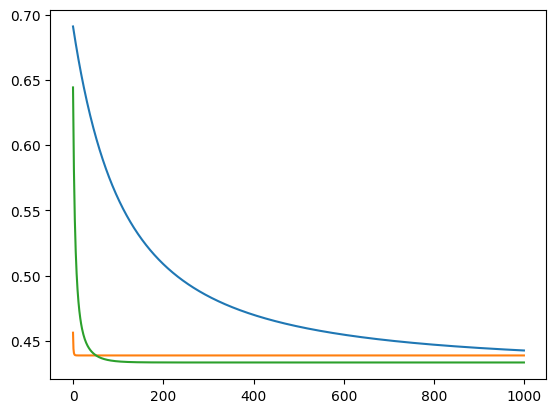

In [23]:
for opt in optimizers:
    print(f"\nTraining with optimizer: {opt.upper()}")
    model = LogisticRegressionModel(lr=0.01, epochs=1000, optimizer=opt, batch_size=32)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[opt] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }

    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1 Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    # Loss Curve
    plt.plot(model.losses, label=f'{opt.upper()}')


In [25]:
# Print summarized results
print("\nSummary of Results:")
for opt, metrics in results.items():
    print(f"{opt.upper()}: {metrics}")


Summary of Results:
GD: {'accuracy': 0.83, 'precision': 0.8214285714285714, 'recall': 0.7840909090909091, 'f1_score': 0.8023255813953488}
SGD: {'accuracy': 0.795, 'precision': 0.7831325301204819, 'recall': 0.7386363636363636, 'f1_score': 0.7602339181286549}
MBGD: {'accuracy': 0.835, 'precision': 0.8089887640449438, 'recall': 0.8181818181818182, 'f1_score': 0.8135593220338984}


In [2]:
!git config --global user.email "khaliddiab2003@gmail.com"

In [14]:
!echo "# optimization" >> README.md
!git init
!git add README.md
!git commit -m "first commit"
!git branch -M main
!git remote add origin https://github.com/AGENT1736/optimization.git
!git push -u origin main

Reinitialized existing Git repository in /content/optimization/.git/
[main (root-commit) 8bc4a32] first commit
 1 file changed, 1 insertion(+)
 create mode 100644 README.md
error: remote origin already exists.
Enumerating objects: 3, done.
Counting objects: 100% (3/3), done.
Writing objects: 100% (3/3), 224 bytes | 224.00 KiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/AGENT1736/optimization.git
 * [new branch]      main -> main
Branch 'main' set up to track remote branch 'main' from 'origin'.


In [22]:
!git add Untitled5.ipynb

fatal: pathspec 'Untitled5.ipynb' did not match any files
